## Linear Regression

- Simple Linear Regression
- Multiple Linear Regression
- Polynomial Regression

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("Data/big_mart_sales.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
X = df[["Item_MRP"]]

y = df["Item_Outlet_Sales"]

In [6]:
X.isnull().sum()

Item_MRP    0
dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
model = LinearRegression()

In [9]:
model.fit(X_train, y_train)

LinearRegression()

In [10]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 15.545463137900196
Intercept: -3.615794332816222


In [11]:
y_pred = model.predict(X_test)

In [12]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
0,1743.0644,1231.163452
1,356.8688,660.309173
2,377.5086,649.999421
3,5778.4782,2696.715098
4,2356.9320,3066.784175
5,865.5400,501.456303
6,4613.9940,3245.805729
7,2410.8618,2204.079371
8,1948.1308,1599.637565
9,1937.4780,2983.410748


In [13]:
# Simple Linear Regression 
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 991.4673771965233


In [14]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1818215.3219161422


In [15]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1348.4121483864428


In [16]:
r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.3310392398178902


In [17]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 991.4673771965233
MSE : 1818215.3219161422
RMSE: 1348.4121483864428
R²  : 0.3310392398178902


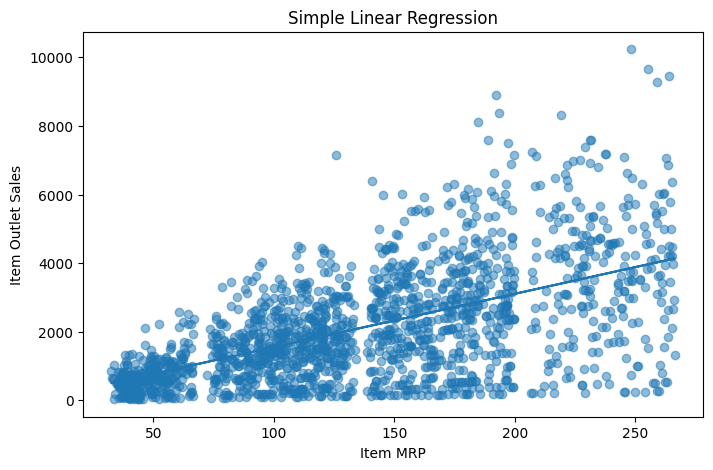

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["Item_MRP"],
    y_test,
    alpha=0.5
)

plt.plot(
    X_test["Item_MRP"],
    y_pred
)

plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")
plt.title("Simple Linear Regression")

plt.show()

## Multiple Linear Regression 

In [ ]:
df["Outlet_Age"] = 2026 - df["Outlet_Establishment_Year"]

In [20]:
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

In [21]:
X = df.drop(columns=["Item_Outlet_Sales"]) 
y = df["Item_Outlet_Sales"]

In [22]:
X = X.drop(columns=[
    "Item_Identifier",
    "Outlet_Identifier",
    "Outlet_Establishment_Year"
])

In [23]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [24]:
print("Numerical:")
print(list(numeric_features))

print("\nCategorical:")
print(list(categorical_features))

Numerical:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']

Categorical:
['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [26]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [27]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [28]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
multiple_linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [31]:
multiple_linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [32]:
y_pred_multiple = multiple_linear_model.predict(X_test)

In [33]:
print(
    "MAE:",
    mean_absolute_error(y_test, y_pred_multiple)
)

print(
    "MSE:",
    mean_squared_error(y_test, y_pred_multiple)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_test, y_pred_multiple)
    )
)

print(
    "R²:",
    r2_score(y_test, y_pred_multiple)
)

MAE: 791.5958131503254
MSE: 1142642.130235532
RMSE: 1068.9443999738864
R²: 0.5795972353522378


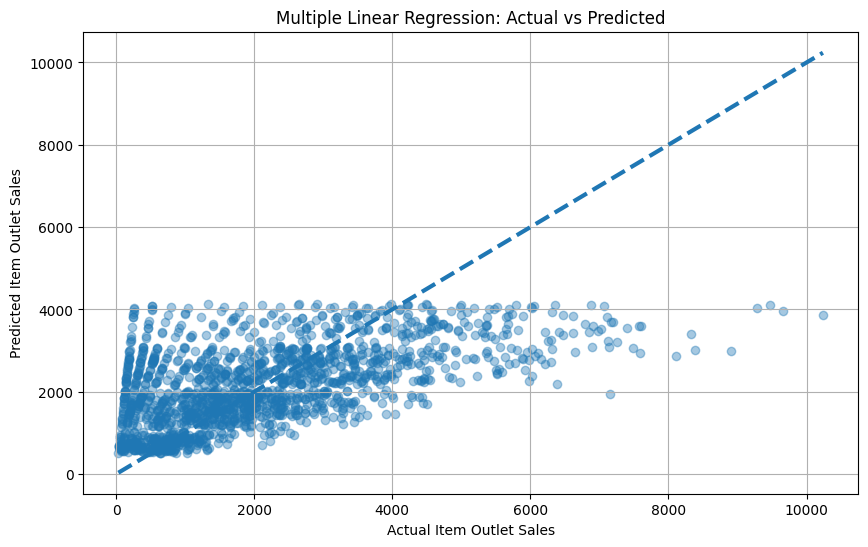

In [41]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=3
)

plt.xlabel("Actual Item Outlet Sales")
plt.ylabel("Predicted Item Outlet Sales")

plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.grid(True)

plt.show()

## Polynomial Regression

In [34]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

In [35]:
poly_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("poly", PolynomialFeatures(
                degree=2,
                include_bias=False
            )),
            ("scaler", StandardScaler())
        ]),
        numeric_features
    ),
    
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore"
            ))
        ]),
        categorical_features
    )
])

In [36]:
polynomial_model = Pipeline([
    ("preprocessor", poly_preprocessor),
    ("model", Ridge(alpha=10))
])

In [37]:
polynomial_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object'))])),
                ('model', Ridge(alpha=10))])

In [38]:
y_pred_poly = polynomial_model.predict(X_test)

In [39]:
print(
    "MAE:",
    mean_absolute_error(y_test, y_pred_poly)
)

print(
    "MSE:",
    mean_squared_error(y_test, y_pred_poly)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_test, y_pred_poly)
    )
)

print(
    "R²:",
    r2_score(y_test, y_pred_poly)
)

MAE: 788.9696782159542
MSE: 1143602.969918364
RMSE: 1069.3937394235877
R²: 0.579243721641902


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load dataset
df = pd.read_csv("Data/big_mart_sales.csv")

# X and y
X = df[["Item_MRP"]]
y = df["Item_Outlet_Sales"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create polynomial features
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Model
model = LinearRegression()

# Train
model.fit(X_train_poly, y_train)

# Prediction
y_pred = model.predict(X_test_poly)

# Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 991.4189199704483
MSE : 1818381.948328992
RMSE: 1348.4739331292215
R²  : 0.3309779343550757


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


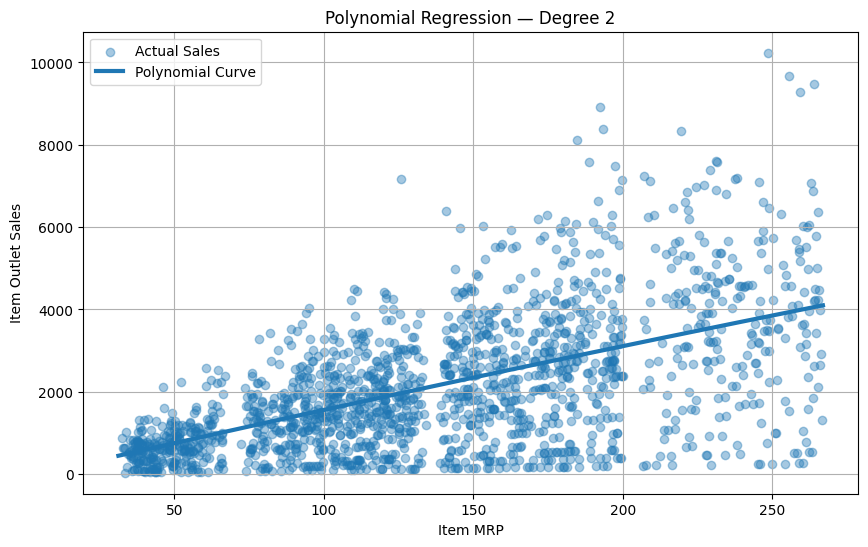

In [47]:
# Create smooth X values
X_range = np.linspace(
    X["Item_MRP"].min(),
    X["Item_MRP"].max(),
    300
).reshape(-1, 1)

# Convert to polynomial
X_range_poly = poly.transform(X_range)

# Predict
y_range_pred = model.predict(X_range_poly)

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["Item_MRP"],
    y_test,
    alpha=0.4,
    label="Actual Sales"
)

plt.plot(
    X_range,
    y_range_pred,
    linewidth=3,
    label="Polynomial Curve"
)

plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")

plt.title("Polynomial Regression — Degree 2")

plt.legend()
plt.grid(True)

plt.show()

In [48]:
poly = PolynomialFeatures(
    degree=3,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()

model.fit(
    X_train_poly,
    y_train
)

y_pred = model.predict(X_test_poly)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 991.2898490057657
MSE : 1818028.9696585014
RMSE: 1348.3430459858876
R²  : 0.33110780284583874


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


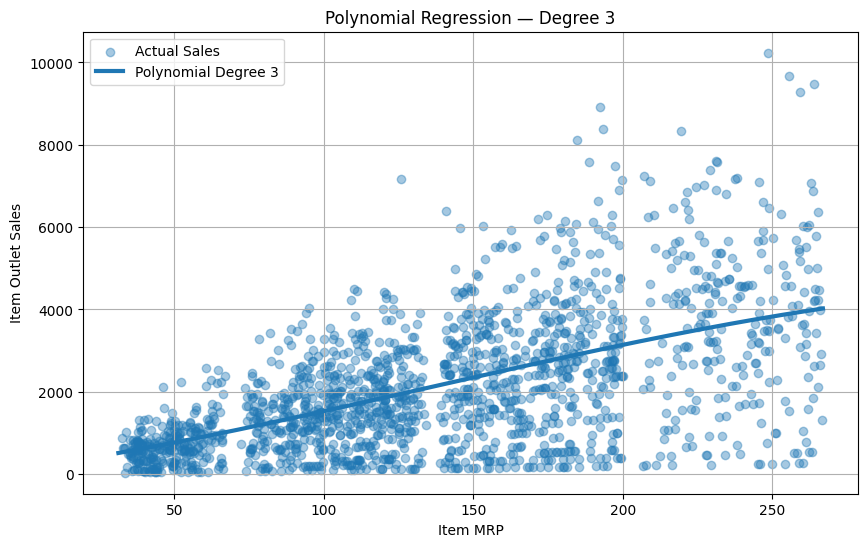

In [49]:
X_range = np.linspace(
    X["Item_MRP"].min(),
    X["Item_MRP"].max(),
    300
).reshape(-1, 1)

X_range_poly = poly.transform(X_range)

y_range_pred = model.predict(X_range_poly)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["Item_MRP"],
    y_test,
    alpha=0.4,
    label="Actual Sales"
)

plt.plot(
    X_range,
    y_range_pred,
    linewidth=3,
    label="Polynomial Degree 3"
)

plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")

plt.title("Polynomial Regression — Degree 3")

plt.legend()
plt.grid(True)

plt.show()